In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix,
ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("CEAS_08.csv")
df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [3]:
df.columns

Index(['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls'], dtype='str')

In [4]:
df.shape

(39154, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    39154 non-null  str  
 1   receiver  38692 non-null  str  
 2   date      39154 non-null  str  
 3   subject   39126 non-null  str  
 4   body      39154 non-null  str  
 5   label     39154 non-null  int64
 6   urls      39154 non-null  int64
dtypes: int64(2), str(5)
memory usage: 66.3 MB


In [6]:
df.describe()

,label,urls
count,39154.000000,39154.00000
mean,0.557848,0.66997
std,0.496649,0.47023
min,0.000000,0.00000
25%,0.000000,0.00000
50%,1.000000,1.00000
75%,1.000000,1.00000
max,1.000000,1.00000


In [7]:
df.isnull().sum()

sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64

In [8]:
df["subject"] = df["subject"].fillna("")

In [9]:
df["receiver"] = df["receiver"].fillna("")

In [10]:
df.isnull().sum()

sender      0
receiver    0
date        0
subject     0
body        0
label       0
urls        0
dtype: int64

In [11]:
df["label"].value_counts()

label
1    21842
0    17312
Name: count, dtype: int64

In [12]:
df["label"].value_counts(normalize=True) * 100

label
1    55.78485
0    44.21515
Name: proportion, dtype: float64

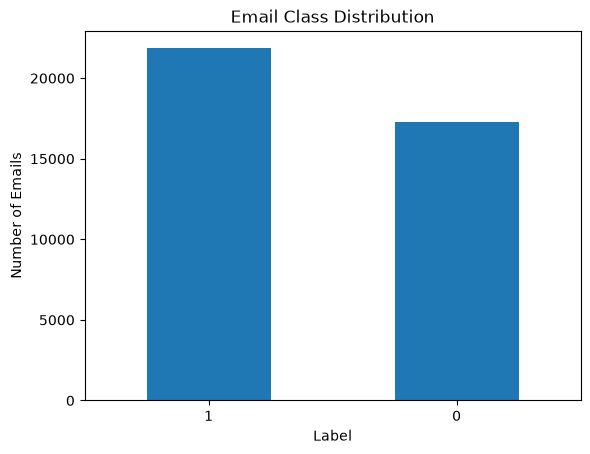

In [13]:
import matplotlib.pyplot as plt
df["label"].value_counts().plot(kind="bar")
plt.title("Email Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.show()

In [14]:
df["email_text"] = df["subject"] + " " + df["body"]

In [15]:
print(df["email_text"].iloc[0])

Never agree to be a loser Buck up, your troubles caused by small dimension will soon be over!
Become a lover no woman will be able to resist!
http://whitedone.com/


come. Even as Nazi tanks were rolling down the streets, the dreamersphilosopher or a journalist. He was still not sure.I do the same.


In [16]:
X = df["email_text"]
y = df["label"]

In [17]:
X.head()
y.head()

0    1
1    1
2    1
3    0
4    1
Name: label, dtype: int64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(

X,
y,
test_size=0.20,
random_state=42,
stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 31323
Testing samples: 7831


In [19]:
vectorizer = TfidfVectorizer(

lowercase=True,
stop_words="english",
max_features=10000,
ngram_range=(1, 2)
)

In [20]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [21]:
X_test_tfidf = vectorizer.transform(X_test)

In [22]:
print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (31323, 10000)
Testing TF-IDF Shape: (7831, 10000)


In [23]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[13850.,17473.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.82,-0.58]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 10000)","[[61.76, 5.97, 0.65,..., 1.98,14.66,13.64], [17.12, 0.4 , 0.62,..., 0. , 0. , 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 10000)","[[ -7.5 , -9.7 ,-11.14,...,-10.55, -8.89, -8.95], [ -8.74,-11.3 ,-11.16,...,-11.64,-11.64,-11.64]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [24]:
y_pred = model.predict(X_test_tfidf)

In [25]:
print("Actual labels:")
print(y_test.head(10).values)
print("\nPredicted labels:")
print(y_pred[:10])

Actual labels:
[1 0 0 1 1 1 1 1 0 0]

Predicted labels:
[1 0 0 1 1 1 1 1 0 0]


In [26]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9791852892350913
Accuracy Percentage: 97.91852892350913 %


In [27]:
precision = precision_score(

y_test,
y_pred,
average="weighted"
)
recall = recall_score(
y_test,
y_pred,
average="weighted"
)
f1 = f1_score(
y_test,
y_pred,
average="weighted"
)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9799170845724573
Recall: 0.9791852892350913
F1 Score: 0.9792227277664736


In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3462
           1       1.00      0.96      0.98      4369

    accuracy                           0.98      7831
   macro avg       0.98      0.98      0.98      7831
weighted avg       0.98      0.98      0.98      7831



In [29]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3452   10]
 [ 153 4216]]


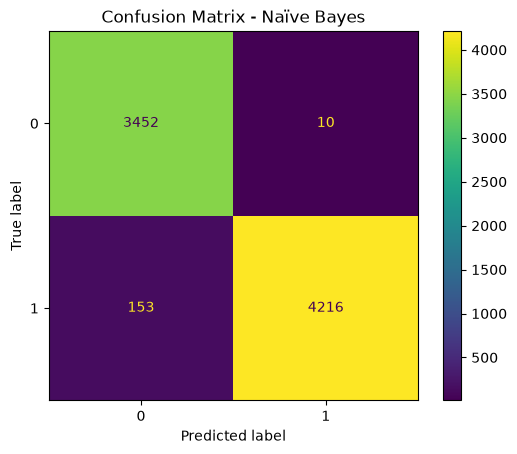

In [30]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)
disp.plot()
plt.title("Confusion Matrix - Naïve Bayes")
plt.show()

In [31]:
new_email = [
"""
Dear Customer,
Your bank account has been suspended.
Please click the link below immediately to verify
your account and confirm your password.
"""
]

In [32]:
new_email_tfidf = vectorizer.transform(new_email)

In [33]:
prediction = model.predict(new_email_tfidf)
print("Prediction:", prediction)

Prediction: [0]


In [35]:
if prediction[0] == 1:
    print("Result: PHISHING / SPAM EMAIL")
else:
    print("Result: LEGITIMATE EMAIL")

Result: LEGITIMATE EMAIL


In [36]:
probability = model.predict_proba(new_email_tfidf)
print(probability)

[[0.60199376 0.39800624]]


In [37]:
print("Probability of Class 0:", probability[0][0])
print("Probability of Class 1:", probability[0][1])

Probability of Class 0: 0.601993764561082
Probability of Class 1: 0.39800623543891944
